# Multi-class Classification

In [20]:
import torch
import torch.nn as nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path
import requests

if not Path('helper_functions.py').is_file():
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open('helper_functions.py', 'wb') as f:
        f.write(request.content)

from helper_functions import plot_decision_boundary

## Create dataset

In [21]:
MANUAL_SEED = 42
NUM_SAMPLES = 1000
NUM_CLASSES = 4
NUM_FEATURES = 2

X, y = make_blobs(n_samples=NUM_SAMPLES, 
                  n_features=NUM_FEATURES, 
                  centers=NUM_CLASSES, 
                  cluster_std=1.5, 
                  random_state=MANUAL_SEED)

# Since y is in the form of [0, 1, 1...], lets convert it to one hot embedding
y = nn.functional.one_hot(torch.from_numpy(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=MANUAL_SEED)

print('Visualize the data')
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

print('\nVisualize the first 5 data')
print(X_train[:5])
print(y_train[:5])

Visualize the data
X_train shape:  (800, 2)
X_test shape:  (200, 2)
y_train shape:  torch.Size([800, 4])
y_test shape:  torch.Size([200, 4])

Visualize the first 5 data
[[ 5.04045424  3.30761588]
 [-2.62485019  9.52601409]
 [-8.52403982 -9.04018592]
 [-6.02615257 -4.43751466]
 [-3.33967158  7.21746929]]
tensor([[0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [1, 0, 0, 0]])


## Visualize dataset

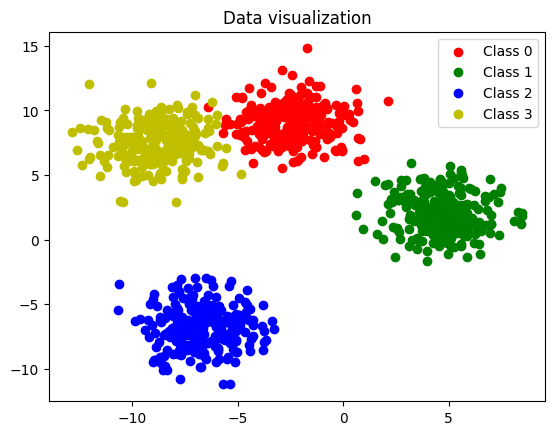

In [22]:
# Visualize dataset
plt.scatter(X[(torch.argmax(y,dim=1).squeeze())==0, 0], X[(torch.argmax(y,dim=1).squeeze())==0, 1], c='r', label='Class 0')
plt.scatter(X[(torch.argmax(y,dim=1).squeeze())==1, 0], X[(torch.argmax(y,dim=1).squeeze())==1, 1], c='g', label='Class 1')
plt.scatter(X[(torch.argmax(y,dim=1).squeeze())==2, 0], X[(torch.argmax(y,dim=1).squeeze())==2, 1], c='b', label='Class 2')
plt.scatter(X[(torch.argmax(y,dim=1).squeeze())==3, 0], X[(torch.argmax(y,dim=1).squeeze())==3, 1], c='y', label='Class 3')
plt.title('Data visualization')
plt.legend()



## Build a model

In [23]:
class MultiClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)


## Training

In [24]:
# Seed
torch.manual_seed(MANUAL_SEED)
torch.cuda.manual_seed(MANUAL_SEED)

# Hyperparameter
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 5000
LEARNING_RATE = 0.1

# Put model and data to the respective device
model_0 = MultiClassificationModel(num_classes=NUM_CLASSES).to(device)
X_train, X_test, y_train, y_test = torch.from_numpy(X_train).to(device).to(torch.float32), torch.from_numpy(X_test).to(device).to(torch.float32), y_train.to(device).to(torch.float32), y_test.to(device).to(torch.float32)


# Loss, optimizer, accuracy
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=LEARNING_RATE)
def acc_fn(y_preds, y_true):
    y_target_preds = torch.argmax(y_true, dim=1).squeeze()
    y_input_preds = torch.argmax(y_preds, dim=1).squeeze()
    correct = torch.eq(y_input_preds, y_target_preds).sum().item()
    return round((correct / len(y_preds)) * 100, 2)

# Track results
plt_epochs = []
plt_train_losses = []
plt_test_losses = []
plt_train_accs = []
plt_test_accs = []

for epoch in range(EPOCHS):

    # Train
    model_0.train()
    y_logits = model_0(X_train)
    y_preds = torch.softmax(y_logits, dim=1)

    train_loss = loss_fn(y_preds, y_train)
    train_acc = acc_fn(y_preds, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Validation
    model_0.eval()
    with torch.inference_mode():
        y_logits = model_0(X_test)
        y_preds = torch.softmax(y_logits, dim=1)

        test_loss = loss_fn(y_preds, y_test)
        test_acc = acc_fn(y_preds, y_test)
    
    if epoch % 100 == 0:
        # Print results
        print('Epoch: ', epoch)
        print(f'Train loss: {train_loss.item():.2f} | Train Acc: {train_acc}')
        print(f'Test loss: {test_loss.item():.2f} | Test Acc: {test_acc}')

        # Keep track of plot results
        plt_epochs.append(epoch)
        plt_train_losses.append(train_loss.item())
        plt_test_losses.append(test_loss.item())
        plt_train_accs.append(train_acc)
        plt_test_accs.append(test_acc)

Epoch:  0
Train loss: 1.42 | Train Acc: 2.75
Test loss: 1.35 | Test Acc: 34.5
Epoch:  100
Train loss: 0.75 | Train Acc: 99.38
Test loss: 0.75 | Test Acc: 99.5
Epoch:  200
Train loss: 0.75 | Train Acc: 99.5
Test loss: 0.74 | Test Acc: 100.0
Epoch:  300
Train loss: 0.75 | Train Acc: 99.5
Test loss: 0.74 | Test Acc: 100.0
Epoch:  400
Train loss: 0.75 | Train Acc: 99.5
Test loss: 0.74 | Test Acc: 100.0
Epoch:  500
Train loss: 0.75 | Train Acc: 99.62
Test loss: 0.74 | Test Acc: 100.0
Epoch:  600
Train loss: 0.75 | Train Acc: 98.88
Test loss: 0.75 | Test Acc: 99.0
Epoch:  700
Train loss: 0.75 | Train Acc: 99.0
Test loss: 0.74 | Test Acc: 100.0
Epoch:  800
Train loss: 0.76 | Train Acc: 98.88
Test loss: 0.75 | Test Acc: 99.5
Epoch:  900
Train loss: 0.75 | Train Acc: 99.12
Test loss: 0.74 | Test Acc: 100.0
Epoch:  1000
Train loss: 0.75 | Train Acc: 99.12
Test loss: 0.74 | Test Acc: 100.0
Epoch:  1100
Train loss: 0.75 | Train Acc: 99.25
Test loss: 0.74 | Test Acc: 100.0
Epoch:  1200
Train loss: 

## Visualize losses evolution

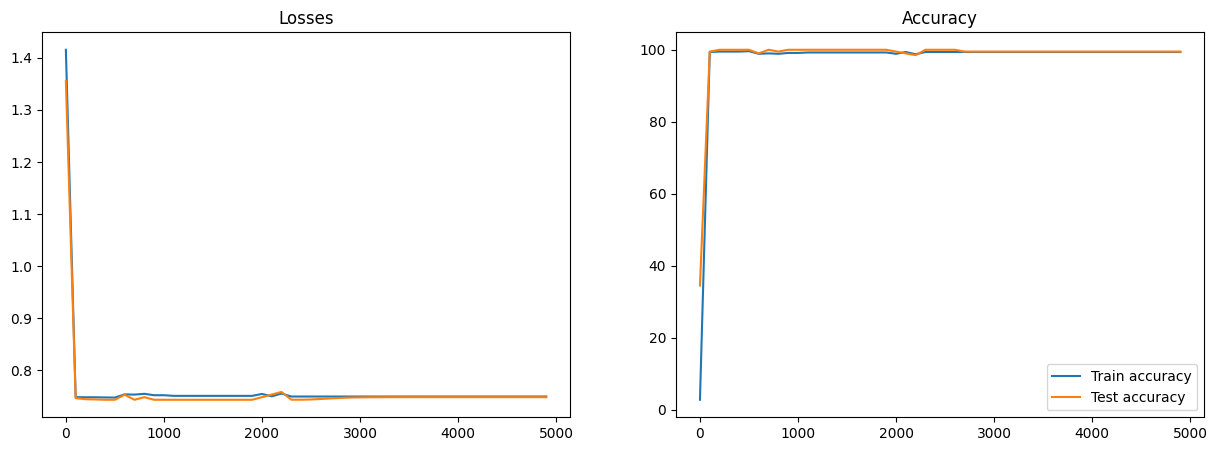

In [25]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Losses')
plt.plot(plt_epochs, plt_train_losses, label='Train loss')
plt.plot(plt_epochs, plt_test_losses, label='Test loss')
plt.subplot(1,2,2)
plt.title('Accuracy')
plt.plot(plt_epochs, plt_train_accs, label='Train accuracy')
plt.plot(plt_epochs, plt_test_accs, label='Test accuracy')
plt.legend()

## Visualize result

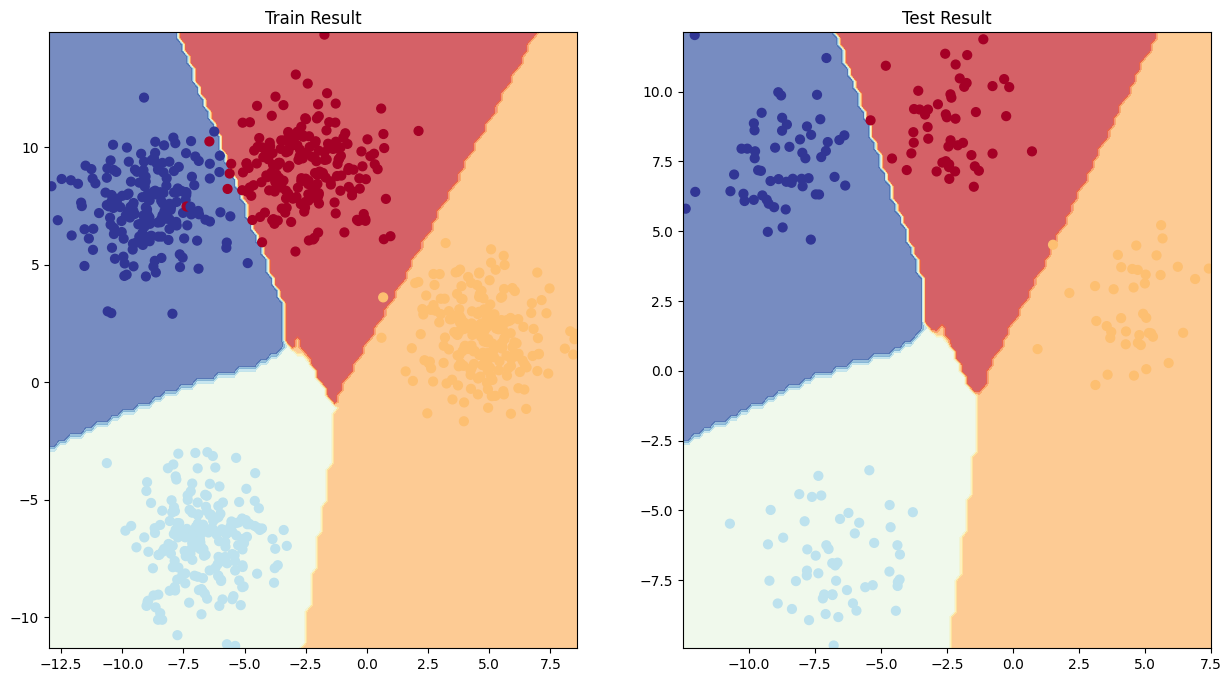

In [26]:
# Visualize result
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title('Train Result')
plot_decision_boundary(model_0, X_train, torch.argmax(y_train, dim=1).squeeze())
plt.subplot(1, 2, 2)
plt.title('Test Result')
plot_decision_boundary(model_0, X_test, torch.argmax(y_test, dim=1).squeeze())

## Save models

In [27]:
save_folder = Path('models')
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder / 'model_0.pt'
torch.save(model_0.state_dict(), save_path)

## Load models

In [28]:
model_1 = MultiClassificationModel(num_classes=NUM_CLASSES).to(device)
model_1.load_state_dict(torch.load(save_path, weights_only=True))

# Test if it works
model_1.eval()
with torch.inference_mode():
    y_logits = model_1(X_test)
    y_preds = torch.softmax(y_logits, dim=1)
    acc = acc_fn(y_preds, y_test)
    print(f'The loaded model has an accuracy of {acc}% on the test data')

The loaded model has an accuracy of 99.5% on the test data
